In [1]:
import pandas as pd
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
   "Esempio_Appello (C3).xlsx"
]
appelli = {}
for f in files:
    df_raw = pd.read_excel(f, header=None)
    inf = df_raw.iloc[:18]
    voti = pd.read_excel(f, header=20)
    key = f.split("(")[1].split(")")[0]

    appelli[key] = {
        "inf": inf,
        "voti": voti
    }


appelli["C2"]["voti"].columns

Index(['#', 'Unnamed: 1', 'Matricola', 'Cognome', 'Nome', 'Anno Freq.', 'CFU',
       'Unnamed: 7', 'Esito', 'Svolgimento Esame', 'Domande d'esame',
       'Data superamento', 'Nota per lo studente', 'Presa Visione', 'CDS COD.',
       'AD COD.', 'Misure Compensative', 'Email'],
      dtype='object')

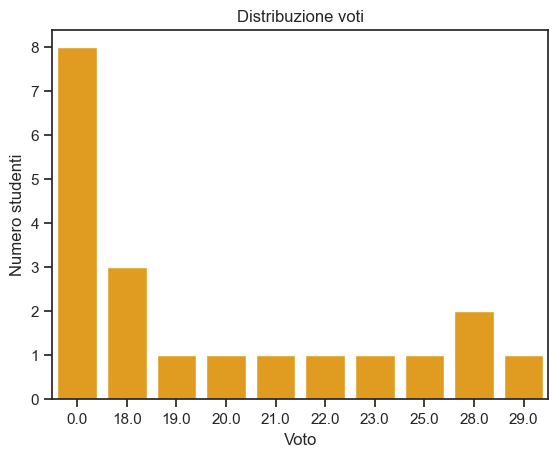

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")
serie = voti["Esito"].astype(str).str.strip()
serie = serie.replace("30L", 31)
voti_num = pd.to_numeric(serie, errors="coerce")
voti_validi = voti_num.dropna()
conteggio = voti_validi.value_counts().sort_index()
conteggio = voti_validi.value_counts().sort_index()

sns.barplot(
    x=conteggio.index,
    y=conteggio.values,
    color="orange"
)

plt.title("Distribuzione voti")
plt.xlabel("Voto")
plt.ylabel("Numero studenti")

plt.show()

In [ ]:
import plotly.graph_objects as go

# Calcolo dei valori
assenti = (serie == "ASS").sum()
ritirati = (serie == "RIT").sum()
promossi = (voti_num >= 18).sum()
bocciati = (voti_num < 18).sum()

categorie = ["Promossi", "Bocciati", "Ritirati", "Assenti"]
valori = [promossi, bocciati, ritirati, assenti]

# Crea il grafico a barre
fig = go.Figure(data=[go.Bar(x=categorie, y=valori, marker_color=['green','red','orange','gray'])])

fig.update_layout(
    title="Esiti Appello",
    yaxis_title="Numero studenti",
    template="plotly_white"
)

# Se vuoi renderizzare in Flask come JSON da passare al template
graph_json = fig.to_json()